# Notebook 00: manual_ec DIV30 Source Checkpoint

This notebook loads one supported source, records source availability, runs the requested `manual_ec` Scanpy QC/filter/preprocess checkpoint, and writes run-scoped tables and plots.

Supported forward sources:

- `cellranger_filtered`
- `cellbender_denoised`

CellBender files are treated as existing fixed inputs. This notebook does not run CellBender.


In [2]:
from pathlib import Path
import os
import sys

import pandas as pd


def env_bool(name: str, default: bool) -> bool:
    raw = os.environ.get(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "y", "on"}


def env_tuple(name: str, default: tuple[str, ...]) -> tuple[str, ...]:
    raw = os.environ.get(name)
    if raw is None or not raw.strip():
        return default
    normalized = raw.replace(";", ",").replace(":", ",")
    return tuple(part.strip() for part in normalized.split(",") if part.strip())


# Make local package imports work whether the notebook is opened from repo root or notebooks/.
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / "python_notebooks" / "src"
    if src_dir.exists():
        sys.path.insert(0, str(src_dir))
        break

from mge_organoid_python.data_sources import (
    Notebook00SourceConfig,
    find_repo_root,
    load_dataset_result,
    resolve_data_root,
)
from mge_organoid_python.notebook00_plots import (
    PlotConfig,
    plot_highest_expr_genes,
    plot_manual_ec_highly_variable_genes,
    plot_manual_ec_per_sample_highest_expr_genes,
    plot_manual_ec_per_sample_qc_scatter,
    plot_manual_ec_per_sample_qc_violins,
    plot_manual_ec_qc_scatter,
    plot_manual_ec_qc_violin,
    plot_manual_ec_source_comparison_cell_counts,
    plot_manual_ec_source_comparison_qc_metrics,
    plot_sample_counts,
    plot_source_availability,
)
from mge_organoid_python.notebook00_workflow import (
    ManualECFilterSettings,
    ManualECPreprocessSettings,
    apply_manual_ec_filter,
    calculate_qc_metrics,
    concat_samples,
    load_manual_ec_run_outputs,
    manual_ec_preprocess,
    manual_ec_qc_summary,
)


## Configuration

Use `NOTEBOOK00_ACTIVE_SOURCE=cellranger_filtered` for the primary run and `NOTEBOOK00_ACTIVE_SOURCE=cellbender_denoised` for the fixed existing-CellBender comparison run.


In [3]:
REPO_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = resolve_data_root()

ACTIVE_SOURCE = os.environ.get("NOTEBOOK00_ACTIVE_SOURCE", "cellranger_filtered")
SUPPORTED_FORWARD_SOURCES = {"cellranger_filtered", "cellbender_denoised"}
if ACTIVE_SOURCE not in SUPPORTED_FORWARD_SOURCES:
    raise ValueError(f"Notebook 00 manual_ec supports {sorted(SUPPORTED_FORWARD_SOURCES)}; got {ACTIVE_SOURCE!r}")

TARGET_DIVS = env_tuple("NOTEBOOK00_TARGET_DIVS", ("DIV30",))
TARGET_RUN_SAMPLE_IDS = env_tuple(
    "NOTEBOOK00_TARGET_RUN_SAMPLE_IDS",
    (
        "9853-MW-1",
        "9853-MW-2",
        "9853-MW-3",
        "9853-MW-4",
        "9853-MW-5",
        "9853-MW-6",
    ),
)
STRICT_MISSING_SOURCES = env_bool("NOTEBOOK00_STRICT_MISSING_SOURCES", False)
LOAD_MATRICES = env_bool("NOTEBOOK00_LOAD_MATRICES", True)
COMPARE_RUN_LABELS = env_tuple("NOTEBOOK00_COMPARE_RUN_LABELS", ())

RUN_LABEL = os.environ.get("NOTEBOOK00_RUN_LABEL") or f"{ACTIVE_SOURCE}_manual_ec_{'_'.join(TARGET_DIVS).lower()}_core_samples"
RUN_DIR = DATA_ROOT / "results" / "notebook00" / RUN_LABEL
TABLE_DIR = RUN_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plot_config = PlotConfig.from_root(
    DATA_ROOT,
    run_label=RUN_LABEL,
    show=env_bool("NOTEBOOK00_SHOW_PLOTS", True),
    save=env_bool("NOTEBOOK00_SAVE_PLOTS", True),
)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("ACTIVE_SOURCE:", ACTIVE_SOURCE)
print("TARGET_DIVS:", TARGET_DIVS)
print("TARGET_RUN_SAMPLE_IDS:", TARGET_RUN_SAMPLE_IDS)
print("STRICT_MISSING_SOURCES:", STRICT_MISSING_SOURCES)
print("LOAD_MATRICES:", LOAD_MATRICES)
print("COMPARE_RUN_LABELS:", COMPARE_RUN_LABELS)
print("RUN_DIR:", RUN_DIR)
print("PLOT_DIR:", plot_config.output_dir)
print("TABLE_DIR:", TABLE_DIR)


REPO_ROOT: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
DATA_ROOT: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
ACTIVE_SOURCE: cellranger_filtered
TARGET_DIVS: ('DIV30',)
TARGET_RUN_SAMPLE_IDS: ('9853-MW-1', '9853-MW-2', '9853-MW-3', '9853-MW-4', '9853-MW-5', '9853-MW-6')
STRICT_MISSING_SOURCES: False
LOAD_MATRICES: True
COMPARE_RUN_LABELS: ()
RUN_DIR: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/notebook00/cellranger_filtered_manual_ec_div30_core_samples
PLOT_DIR: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/notebook00/cellranger_filtered_manual_ec_div30_core_samples/plots
TABLE_DIR: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/notebook00/cellranger_filtered_manual_ec_div30_core_samples/tables


## Source Availability

This reports requested sample paths before loading matrices.


,DIV,run_sample_id,biological_label,cell_line,data_source,matrix_source,matrix_dir,matrix_exists,source_path,source_exists,load_status,skip_reason,loaded_in_memory
0,DIV30,9853-MW-1,H9_rep1,H9,cellranger_filtered,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,available,,False
1,DIV30,9853-MW-2,H9_rep2,H9,cellranger_filtered,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,available,,False
2,DIV30,9853-MW-3,79B_rep1,79B,cellranger_filtered,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,available,,False
3,DIV30,9853-MW-4,79B_rep2,79B,cellranger_filtered,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,available,,False
4,DIV30,9853-MW-5,2E_rep1,2E,cellranger_filtered,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,available,,False
5,DIV30,9853-MW-6,2E_rep2,2E,cellranger_filtered,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...,True,available,,False


,data_source,load_status,n_samples
0,cellranger_filtered,available,6


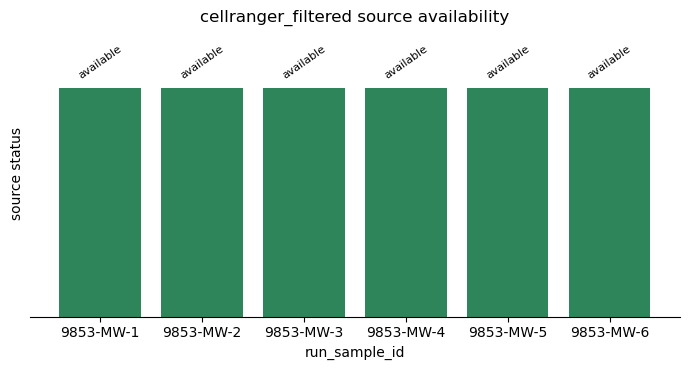

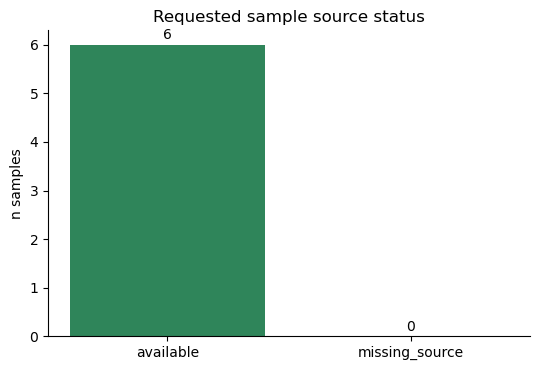

PosixPath('/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/results/notebook00/cellranger_filtered_manual_ec_div30_core_samples/plots/loaded_vs_skipped_counts.png')

In [4]:
source_config = Notebook00SourceConfig.from_defaults(
    data_source=ACTIVE_SOURCE,
    repo_root=REPO_ROOT,
    data_root=DATA_ROOT,
    target_divs=TARGET_DIVS,
    target_run_sample_ids=TARGET_RUN_SAMPLE_IDS,
    strict_missing_matrix_dirs=STRICT_MISSING_SOURCES,
)

source_preview = load_dataset_result(source_config, load_matrices=False)
source_table = source_preview.source_table
source_summary_df = source_preview.availability_summary()

source_table.to_csv(TABLE_DIR / "source_table.tsv", sep="	", index=False)
source_summary_df.to_csv(TABLE_DIR / "source_summary.tsv", sep="	", index=False)

display(source_table)
display(source_summary_df)

plot_source_availability(source_table, plot_config)
plot_sample_counts(source_table, plot_config)


## Load Available Samples

Only available samples are loaded when `STRICT_MISSING_SOURCES=False`. Set `NOTEBOOK00_LOAD_MATRICES=0` for source/report-only or comparison-only runs.


In [5]:
if LOAD_MATRICES:
    dataset_result = load_dataset_result(source_config, load_matrices=True)
    sample_adata_names = dataset_result.adata_names
    sample_adata_list = dataset_result.adata_list
    source_table = dataset_result.source_table
else:
    dataset_result = source_preview
    sample_adata_names = []
    sample_adata_list = []
    source_table = source_preview.source_table.copy()
    print("LOAD_MATRICES is False; generated source reports only and skipped AnnData loading.")

# Backward-compatible aliases for older notebook snippets.
adata_names = sample_adata_names
adata_list = sample_adata_list

source_table.to_csv(TABLE_DIR / "loaded_source_table.tsv", sep="	", index=False)

print("Loaded samples:", dataset_result.loaded_samples)
print("Skipped samples:", dataset_result.skipped_samples)
print("Number of sample AnnData objects:", len(sample_adata_list))

loaded_shape_df = pd.DataFrame(
    {
        "run_sample_id": run_sample_id,
        "n_obs": one_sample_adata.n_obs,
        "n_vars": one_sample_adata.n_vars,
        "obs_names_unique": one_sample_adata.obs_names.is_unique,
        "data_source": one_sample_adata.obs["data_source"].iloc[0] if "data_source" in one_sample_adata.obs else ACTIVE_SOURCE,
    }
    for run_sample_id, one_sample_adata in zip(sample_adata_names, sample_adata_list)
)
loaded_shape_df.to_csv(TABLE_DIR / "loaded_sample_shapes.tsv", sep="	", index=False)
display(loaded_shape_df)


Loaded samples: ['9853-MW-1', '9853-MW-2', '9853-MW-3', '9853-MW-4', '9853-MW-5', '9853-MW-6']
Skipped samples: []
Number of sample AnnData objects: 6


,run_sample_id,n_obs,n_vars,obs_names_unique,data_source
0,9853-MW-1,18047,18082,True,cellranger_filtered
1,9853-MW-2,6060,18082,True,cellranger_filtered
2,9853-MW-3,17928,18082,True,cellranger_filtered
3,9853-MW-4,13047,18082,True,cellranger_filtered
4,9853-MW-5,26408,18082,True,cellranger_filtered
5,9853-MW-6,25530,18082,True,cellranger_filtered


## manual_ec QC, Filtering, And Preprocessing

This is the requested Scanpy checkpoint: highest expressed genes, mitochondrial QC metrics, QC violins/scatters, `filter_cells(min_genes=20)`, `filter_genes(min_cells=3)`, manual biological/QC cutoffs, normalization, log1p, HVG selection, and HVG plot.


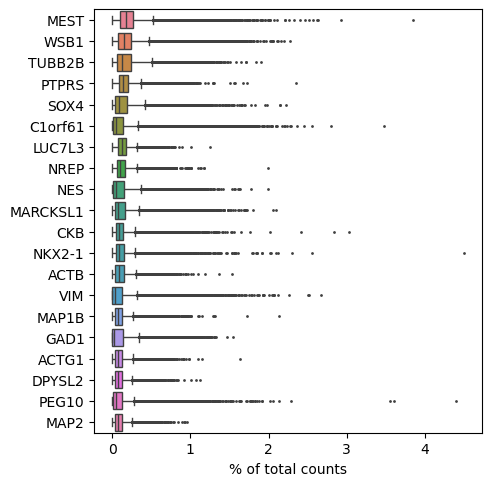

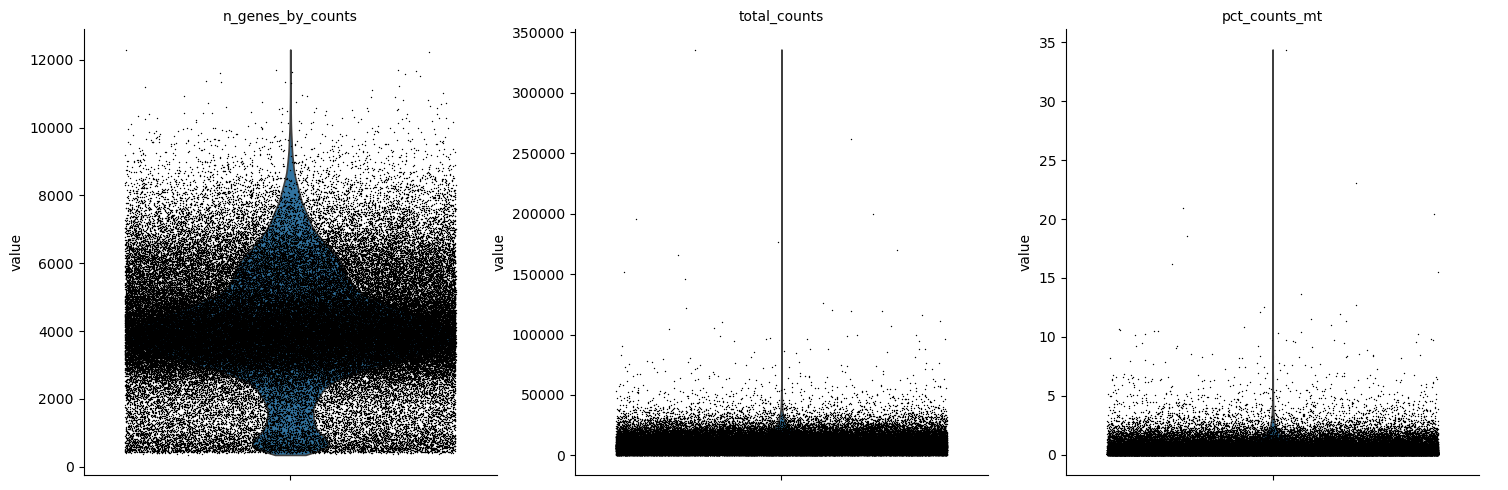

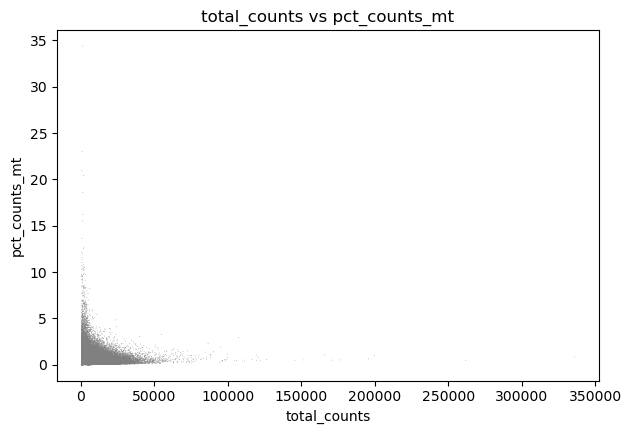

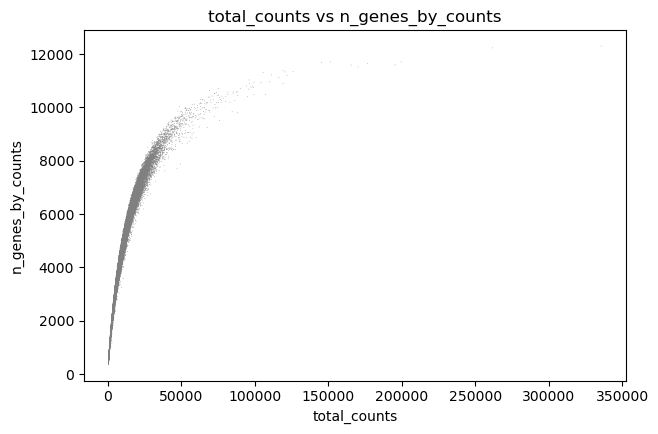

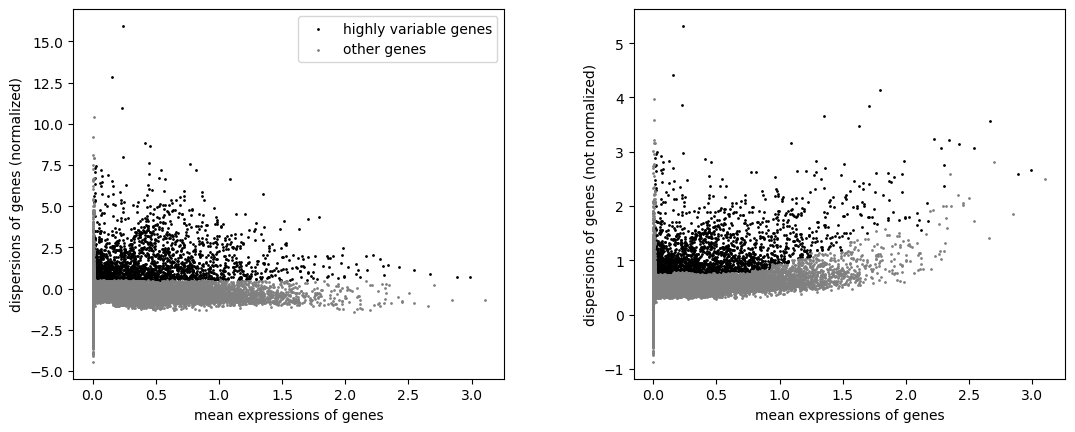

,data_source,run_sample_id,cell_line,starting_n_cells,post_min_gene_cell_filter_n_cells,manual_ec_retained_n_cells,manual_ec_removed_n_cells,manual_ec_retained_pct,starting_n_genes,post_min_cell_filter_n_genes,manual_ec_final_n_genes,elapsed_seconds
0,cellranger_filtered,9853-MW-1,H9,18047,18047,16622,1425,92.103951,18082,17486,17486,37.833764
1,cellranger_filtered,9853-MW-2,H9,6060,6060,4905,1155,80.940594,18082,17486,17486,37.833764
2,cellranger_filtered,9853-MW-3,79B,17928,17928,16627,1301,92.743195,18082,17486,17486,37.833764
3,cellranger_filtered,9853-MW-4,79B,13047,13047,11525,1522,88.334483,18082,17486,17486,37.833764
4,cellranger_filtered,9853-MW-5,2E,26408,26408,24217,2191,91.703272,18082,17486,17486,37.833764
5,cellranger_filtered,9853-MW-6,2E,25530,25530,23762,1768,93.074814,18082,17486,17486,37.833764


,stage,data_source,run_sample_id,cell_line,n_cells,median_n_genes_by_counts,median_total_counts,median_pct_counts_mt,mean_n_genes_by_counts,mean_total_counts,mean_pct_counts_mt
0,manual_ec_filtered,cellranger_filtered,9853-MW-1,H9,16622,3789.0,6937.0,0.248008,3987.547407,8240.160156,0.481738
1,manual_ec_filtered,cellranger_filtered,9853-MW-2,H9,4905,3992.0,7405.0,0.214880,4186.967788,9078.288086,0.536427
2,manual_ec_filtered,cellranger_filtered,9853-MW-3,79B,16627,4235.0,8648.0,0.320125,4347.733987,9776.325195,0.440496
3,manual_ec_filtered,cellranger_filtered,9853-MW-4,79B,11525,3738.0,6729.0,0.155809,3894.123905,7750.738281,0.379766
4,manual_ec_filtered,cellranger_filtered,9853-MW-5,2E,24217,4142.0,7732.0,0.187600,4344.931949,9080.614258,0.336023
5,manual_ec_filtered,cellranger_filtered,9853-MW-6,2E,23762,4396.5,8660.0,0.153151,4638.735292,10365.756836,0.255929


,n_cells,n_genes,n_highly_variable_genes,target_sum,hvg_min_mean,hvg_max_mean,hvg_min_disp,elapsed_seconds
0,97658,17486,2235,10000.0,0.0125,3.0,0.5,8.217847


In [6]:
manual_ec_adata = None
combined_adata = None

if sample_adata_list:
    combined_adata = concat_samples(sample_adata_names, sample_adata_list)
    calculate_qc_metrics(combined_adata, mito_prefix="MT-", log1p=False, overwrite=True)
    manual_ec_qc_summary_loaded_df = manual_ec_qc_summary(combined_adata, stage="loaded")
    manual_ec_qc_summary_loaded_df.to_csv(TABLE_DIR / "manual_ec_qc_summary_loaded.tsv", sep="	", index=False)

    plot_highest_expr_genes(combined_adata, plot_config, n_top=20, name="highest_expr_genes_top20")
    plot_manual_ec_qc_violin(combined_adata, plot_config, name="manual_ec_qc_violin")
    plot_manual_ec_qc_scatter(
        combined_adata,
        plot_config,
        x="total_counts",
        y="pct_counts_mt",
        name="manual_ec_scatter_total_counts_pct_counts_mt",
    )
    plot_manual_ec_qc_scatter(
        combined_adata,
        plot_config,
        x="total_counts",
        y="n_genes_by_counts",
        name="manual_ec_scatter_total_counts_n_genes_by_counts",
    )

    filter_settings = ManualECFilterSettings()
    manual_ec_adata, manual_ec_filter_summary_df, manual_ec_filter_parameters_df = apply_manual_ec_filter(
        combined_adata,
        settings=filter_settings,
    )
    manual_ec_filter_summary_df.to_csv(TABLE_DIR / "manual_ec_filter_summary.tsv", sep="	", index=False)
    manual_ec_filter_parameters_df.to_csv(TABLE_DIR / "manual_ec_filter_parameters.tsv", sep="	", index=False)

    calculate_qc_metrics(manual_ec_adata, mito_prefix="MT-", log1p=False, overwrite=True)
    manual_ec_qc_summary_after_filter_df = manual_ec_qc_summary(manual_ec_adata, stage="manual_ec_filtered")
    manual_ec_qc_summary_after_filter_df.to_csv(
        TABLE_DIR / "manual_ec_qc_summary_after_filter.tsv",
        sep="	",
        index=False,
    )

    preprocess_settings = ManualECPreprocessSettings()
    manual_ec_preprocess_report_df, manual_ec_preprocess_parameters_df, manual_ec_hvg_genes_df = manual_ec_preprocess(
        manual_ec_adata,
        settings=preprocess_settings,
    )
    manual_ec_preprocess_report_df.to_csv(TABLE_DIR / "manual_ec_preprocess_report.tsv", sep="	", index=False)
    manual_ec_preprocess_parameters_df.to_csv(TABLE_DIR / "manual_ec_preprocess_parameters.tsv", sep="	", index=False)
    manual_ec_hvg_genes_df.to_csv(TABLE_DIR / "manual_ec_hvg_genes.tsv", sep="	", index=False)

    plot_manual_ec_highly_variable_genes(manual_ec_adata, plot_config, name="manual_ec_highly_variable_genes")

    # Keep the requested working object name available for interactive inspection.
    adata = manual_ec_adata

    display(manual_ec_filter_summary_df)
    display(manual_ec_qc_summary_after_filter_df)
    display(manual_ec_preprocess_report_df)
else:
    print("No AnnData objects loaded; skipping manual_ec matrix checkpoint.")
    pd.DataFrame().to_csv(TABLE_DIR / "manual_ec_filter_summary.tsv", sep="	", index=False)
    pd.DataFrame().to_csv(TABLE_DIR / "manual_ec_filter_parameters.tsv", sep="	", index=False)
    pd.DataFrame().to_csv(TABLE_DIR / "manual_ec_preprocess_report.tsv", sep="	", index=False)
    pd.DataFrame().to_csv(TABLE_DIR / "manual_ec_preprocess_parameters.tsv", sep="	", index=False)
    pd.DataFrame().to_csv(TABLE_DIR / "manual_ec_hvg_genes.tsv", sep="	", index=False)


## manual_ec Per-Sample QC Plot Grids


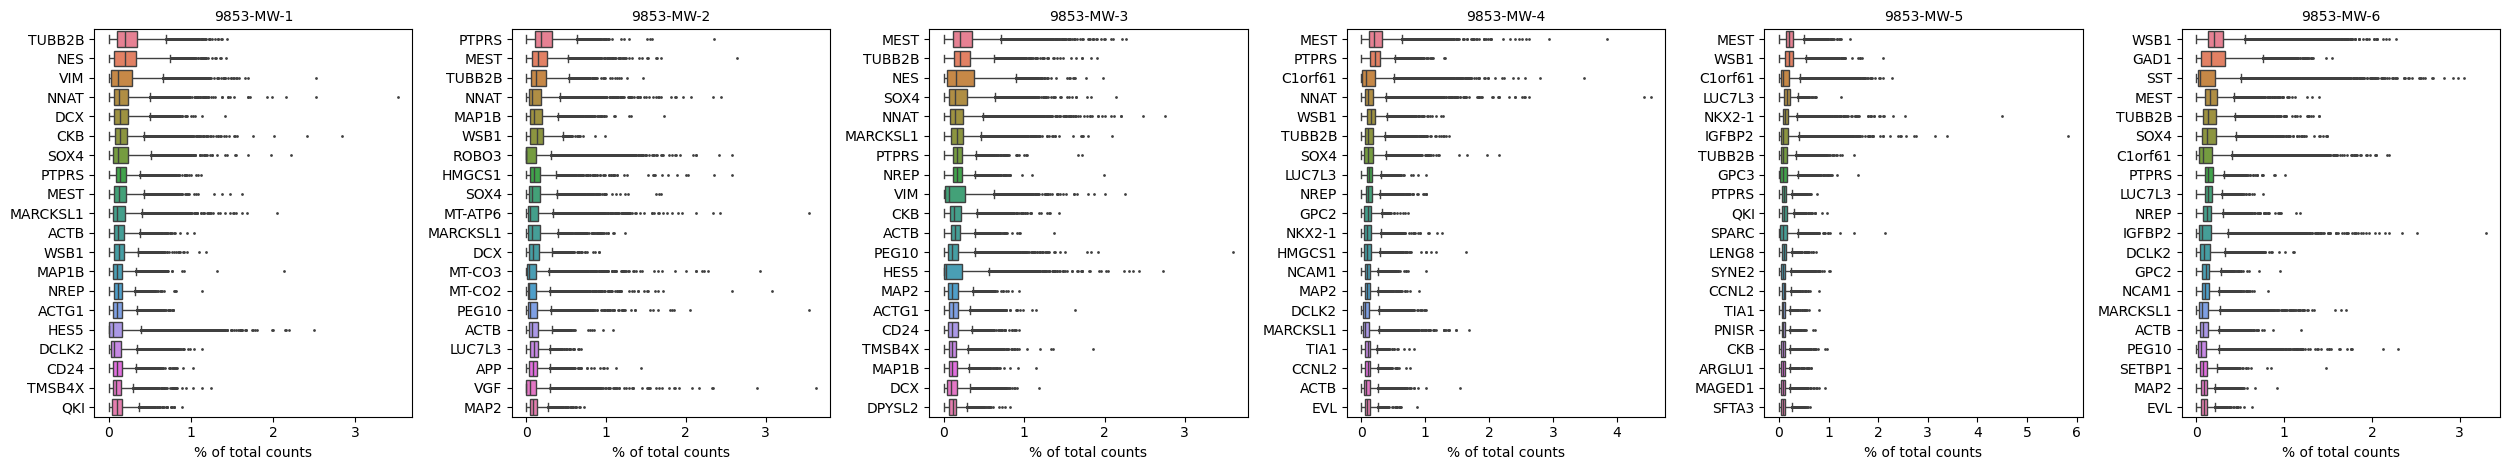

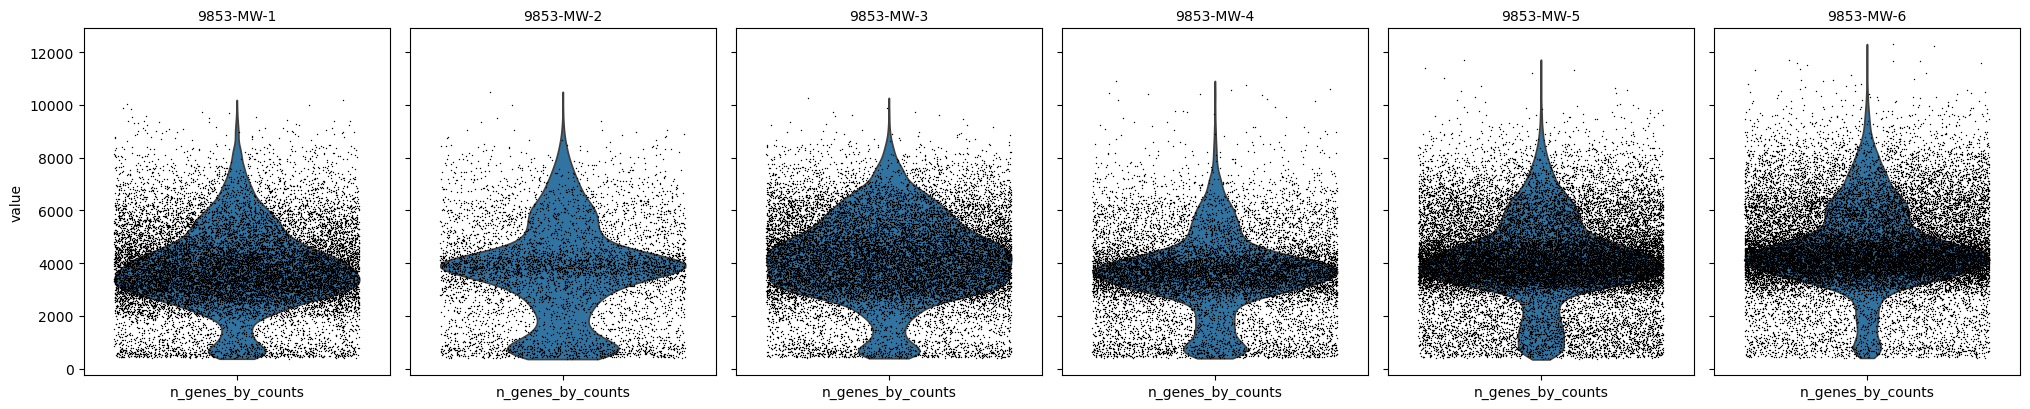

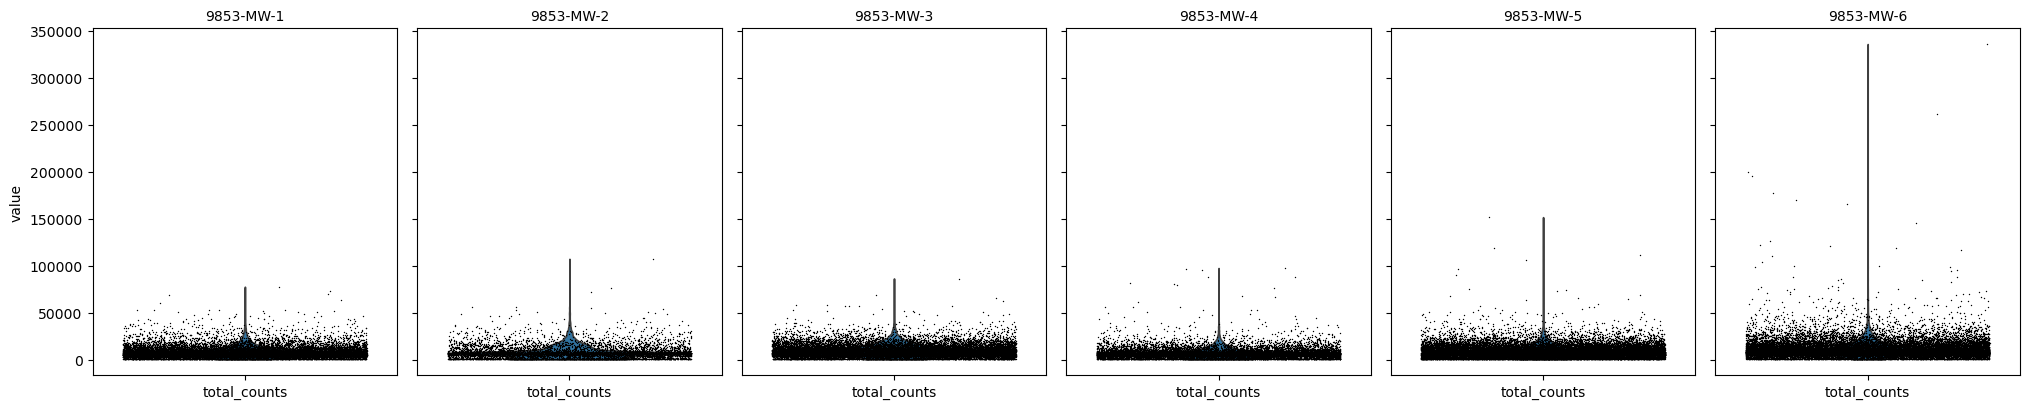

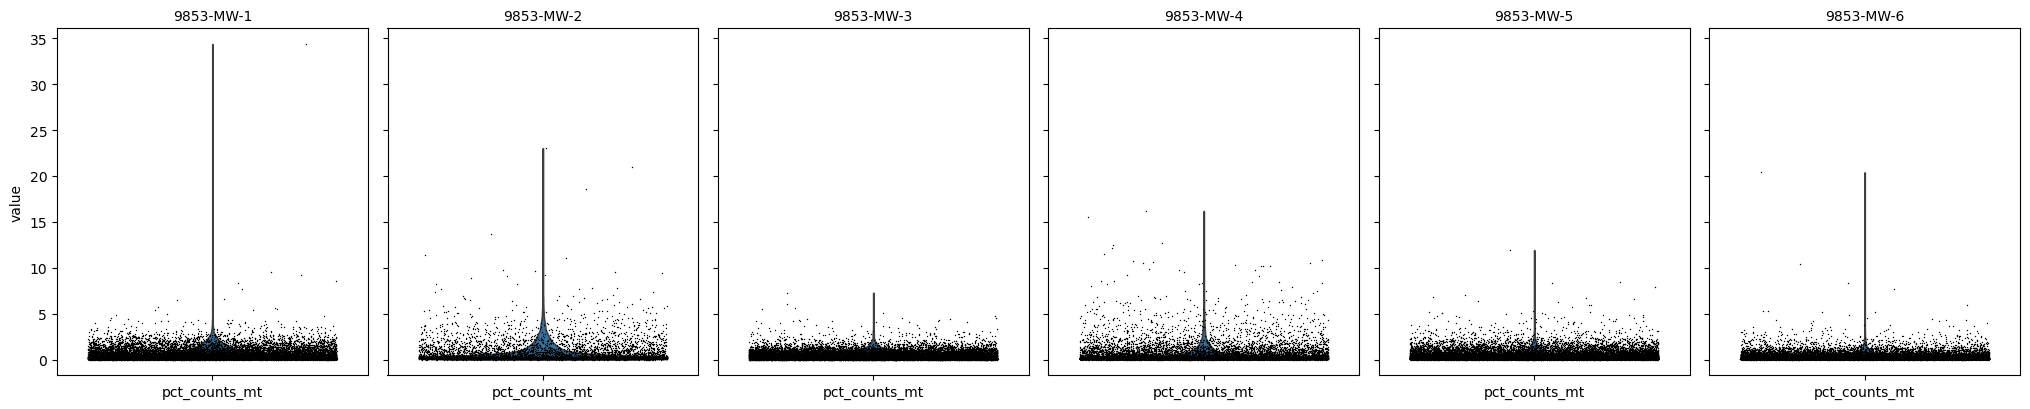

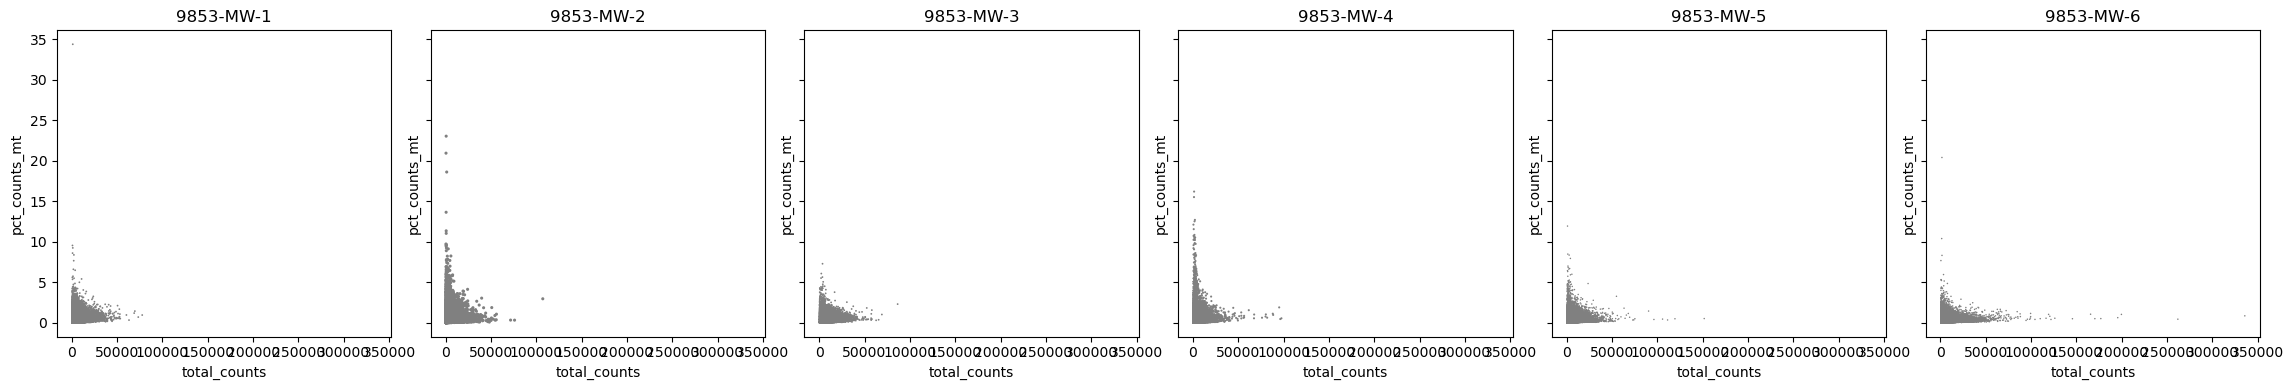

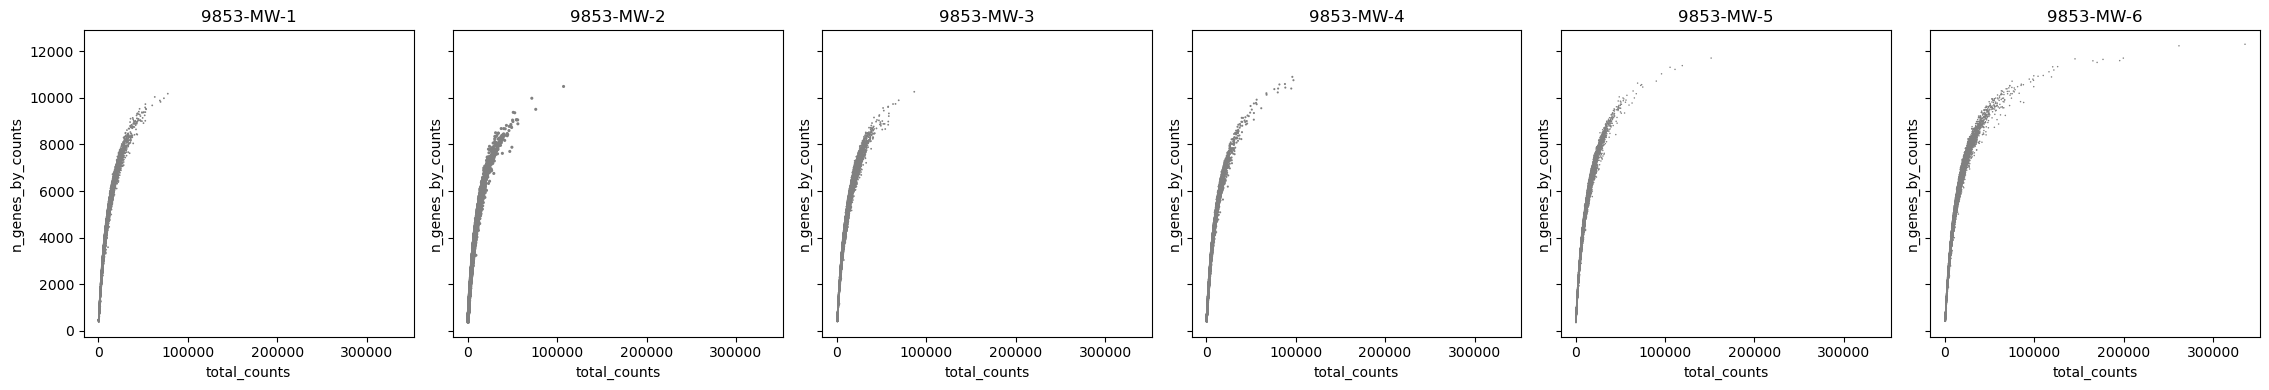

,plot,path
0,highest_expr_genes_top20,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...
1,qc_violin_n_genes_by_counts,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...
2,qc_violin_total_counts,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...
3,qc_violin_pct_counts_mt,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...
4,scatter_total_counts_pct_counts_mt,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...
5,scatter_total_counts_n_genes_by_counts,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...


In [7]:
manual_ec_per_sample_plot_paths = {}

if sample_adata_list:
    for one_sample_adata in sample_adata_list:
        calculate_qc_metrics(one_sample_adata, mito_prefix="MT-", log1p=False, overwrite=True)

    highest_expr_path = plot_manual_ec_per_sample_highest_expr_genes(
        sample_adata_names,
        sample_adata_list,
        plot_config,
        n_top=20,
        name="manual_ec_per_sample_highest_expr_genes_top20",
    )
    if highest_expr_path is not None:
        manual_ec_per_sample_plot_paths["highest_expr_genes_top20"] = highest_expr_path

    violin_paths = plot_manual_ec_per_sample_qc_violins(
        sample_adata_names,
        sample_adata_list,
        plot_config,
        keys=("n_genes_by_counts", "total_counts", "pct_counts_mt"),
        name_prefix="manual_ec_per_sample_qc_violin",
    )
    manual_ec_per_sample_plot_paths.update(
        {f"qc_violin_{metric}": path for metric, path in violin_paths.items() if path is not None}
    )

    total_counts_mt_path = plot_manual_ec_per_sample_qc_scatter(
        sample_adata_names,
        sample_adata_list,
        plot_config,
        x="total_counts",
        y="pct_counts_mt",
        name="manual_ec_per_sample_scatter_total_counts_pct_counts_mt",
    )
    if total_counts_mt_path is not None:
        manual_ec_per_sample_plot_paths["scatter_total_counts_pct_counts_mt"] = total_counts_mt_path

    total_counts_genes_path = plot_manual_ec_per_sample_qc_scatter(
        sample_adata_names,
        sample_adata_list,
        plot_config,
        x="total_counts",
        y="n_genes_by_counts",
        name="manual_ec_per_sample_scatter_total_counts_n_genes_by_counts",
    )
    if total_counts_genes_path is not None:
        manual_ec_per_sample_plot_paths["scatter_total_counts_n_genes_by_counts"] = total_counts_genes_path

    display(
        pd.DataFrame(
            [
                {"plot": plot_name, "path": str(plot_path)}
                for plot_name, plot_path in manual_ec_per_sample_plot_paths.items()
            ]
        )
    )
else:
    print("No AnnData objects loaded; skipping per-sample manual_ec QC plot grids.")


##  Expand code here

In [ ]:
def split_adata_by_sample(
    adata,
    sample_column="run_sample_id",
    sample_names=None,
    copy=True,
):
    """
    Split one combined AnnData object into a list of per-sample AnnData objects.

    Assumptions
    -----------
    - `adata` is one combined AnnData object, for example `manual_ec_adata`.
    - `adata.obs[sample_column]` exists and identifies which sample each cell
      came from.
    - This function does not modify `adata`.
    - This function does not overwrite any notebook variables by itself.
      Variables are only created or overwritten by whatever names you put on
      the left side of the assignment when you call it.

    Parameters
    ----------
    adata : AnnData
        The combined AnnData object to split.

    sample_column : str
        Column in `adata.obs` that stores the sample ID for each cell.
        In this notebook, the expected default is `"run_sample_id"`.

    sample_names : list-like or None
        Optional explicit sample order.
        If None, sample names are taken from `adata.obs[sample_column]` in
        their first-seen order.

    copy : bool
        If True, each returned per-sample AnnData is an independent copy.
        This is safest for interactive work because edits to one sample object
        will not act as views into the original combined object.

    Returns
    -------
    split_sample_names : list[str]
        Sample names used for splitting.

    split_sample_adata_list : list[AnnData]
        One AnnData object per sample, in the same order as
        `split_sample_names`.
    """

    # Make sure the combined AnnData has the metadata column needed to split cells.
    if sample_column not in adata.obs.columns:
        raise KeyError(f"{sample_column!r} not found in adata.obs")

    # Convert sample IDs to strings once so comparisons are stable and predictable.
    sample_series = adata.obs[sample_column].astype(str)

    # If the user did not provide a sample order, preserve the first-seen order
    # from the combined object's obs table.
    if sample_names is None:
        split_sample_names = list(sample_series.drop_duplicates())
    else:
        split_sample_names = [str(sample_name) for sample_name in sample_names]

    split_sample_adata_list = []

    # Build one AnnData object per sample by selecting cells where the sample
    # metadata matches the requested sample name.
    for sample_name in split_sample_names:
        sample_mask = sample_series == sample_name

        # This slice contains only the cells from the current sample.
        one_sample_adata = adata[sample_mask]

        # Copy by default so the returned objects are safe to edit independently
        # in later notebook cells.
        if copy:
            one_sample_adata = one_sample_adata.copy()

        split_sample_adata_list.append(one_sample_adata)

    return split_sample_names, split_sample_adata_list

In [ ]:
manual_ec_filtered_sample_names, manual_ec_filtered_sample_list = split_adata_by_sample(
    manual_ec_adata,
    sample_column="run_sample_id",
)

## Optional manual_ec Source Comparison

Set `NOTEBOOK00_COMPARE_RUN_LABELS` to two completed manual_ec run labels, for example:

```text
cellranger_filtered_manual_ec_div30_core_samples:cellbender_denoised_manual_ec_div30_core_samples
```

Use `:` or `;` as the separator when passing labels through Slurm `--export`; comma-separated values also work inside the notebook. This reads run-scoped tables and writes comparison summaries/plots. It does not load expression matrices.


In [8]:
if COMPARE_RUN_LABELS:
    comparison_outputs = load_manual_ec_run_outputs(DATA_ROOT / "results" / "notebook00", COMPARE_RUN_LABELS)
    for table_name, table_df in comparison_outputs.items():
        table_df.to_csv(TABLE_DIR / f"{table_name}.tsv", sep="	", index=False)
        display(table_df)

    plot_manual_ec_source_comparison_cell_counts(
        comparison_outputs["manual_ec_source_comparison_summary"],
        plot_config,
        name="manual_ec_source_comparison_cell_counts",
    )
    plot_manual_ec_source_comparison_qc_metrics(
        comparison_outputs["manual_ec_qc_metric_comparison_by_sample"],
        plot_config,
        metric="median_n_genes_by_counts",
        name="manual_ec_source_comparison_qc_metrics",
    )
else:
    print("NOTEBOOK00_COMPARE_RUN_LABELS is empty; skipping cross-run comparison.")


NOTEBOOK00_COMPARE_RUN_LABELS is empty; skipping cross-run comparison.


## Generated Objects

Main objects created by this notebook run:

- `source_table`: requested source paths and availability
- `sample_adata_names`, `sample_adata_list`: loaded per-sample objects; one list entry per sample
- `adata_names`, `adata_list`: backward-compatible aliases for the per-sample names/list
- `combined_adata`: concatenated loaded object before manual_ec filtering; combined plots use this object
- `manual_ec_adata` / `adata`: filtered, normalized, log-transformed, HVG-annotated object
- `TABLE_DIR`: saved TSV reports
- `plot_config.output_dir`: saved plot PNGs
